In [1]:
import os

# Chemin vers le dossier des données (on remonte d'un dossier car on est dans notebooks/)
data_path = "../data/raw"

# Lister les catégories (les noms des sous-dossiers)
categories = [c for c in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, c))]
print("Catégories trouvées :", categories)

# Compter le nombre d'images par catégorie
print("\n--- Nombre d'images par catégorie ---")
for category in categories:
    folder_path = os.path.join(data_path, category)
    nb_images = len(os.listdir(folder_path))
    print(f"{category} : {nb_images} images")

Catégories trouvées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

--- Nombre d'images par catégorie ---
cardboard : 403 images
glass : 501 images
metal : 410 images
paper : 594 images
plastic : 482 images
trash : 137 images


On observe un déséquilibre de classes assez net : la catégorie trash n'a que 137 images, alors que les autres en ont entre 400 et 600.Si on entraîne le modèle tel quel, il risque de moins bien apprendre à reconnaître trash simplement parce qu'il a vu beaucoup moins d'exemples de cette catégorie. Le modèle aura tendance à "préférer" prédire les catégories qu'il a vues plus souvent.

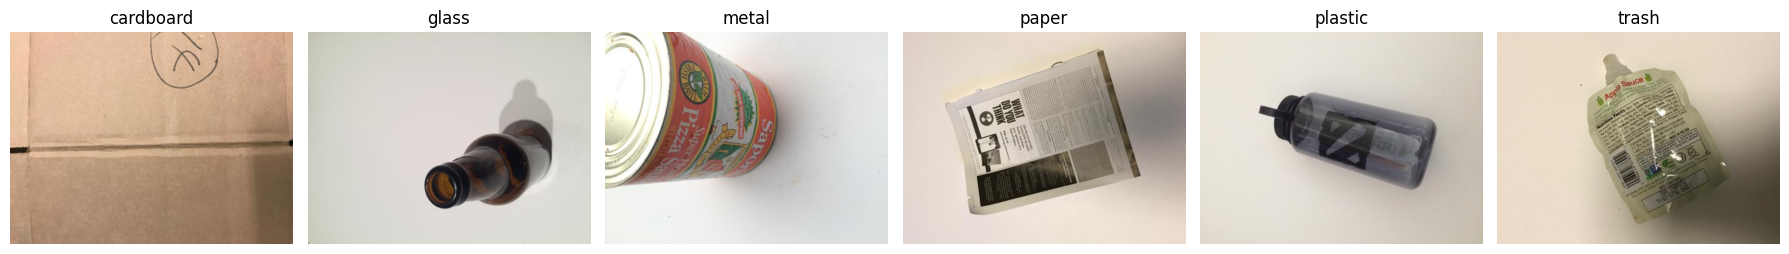

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# Afficher une image d'exemple pour chaque catégorie
fig, axes = plt.subplots(1, len(categories), figsize=(18, 4))

for i, category in enumerate(categories):
    folder_path = os.path.join(data_path, category)
    first_image_name = os.listdir(folder_path)[0]
    image_path = os.path.join(folder_path, first_image_name)
    
    image = Image.open(image_path)
    axes[i].imshow(image)
    axes[i].set_title(category)
    axes[i].axis("off")

plt.tight_layout()
plt.show()